
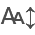

In [142]:
import pandas as pd
import os
import numpy as np
from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import make_scorer, precision_score, f1_score, fbeta_score
from sklearn.model_selection import RandomizedSearchCV
from tensorflow.keras.callbacks import EarlyStopping
import shap
import random
from sklearn.utils import class_weight

from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)

In [31]:
processed_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_processed')
figures_path = os.path.join(os.getcwd(), '..', 'data', 'visualizations')

ustawienie ziarna globalnie

In [32]:
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

In [33]:
df = pd.read_csv(os.path.join(processed_data_input_path, 'initial_features_selected.csv'))

df = df.set_index('Unnamed: 0')
df.index.name = None
df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


In [34]:
benchmark_cols = [
    'season',
    'gameweek',
    'team',
    'opponent',
    'goals_scored',
    'goals_conceded',
    'prob_unexpected_result',
    'elo_unexpected_result',
    'win_probability',
    'draw_probability',
    'not_loss_probability',
    'win_odds',
    'draw_odds',
    'loss_odds'
]
df_benchmark = df[benchmark_cols].copy()
benchmark_cols.remove('prob_unexpected_result')
df = df.drop(columns=benchmark_cols)

df

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


Podział na zbiory - treningowy, walidacyjny, testowy (70/15/15)

In [35]:
n = len(df)
train_end = int(n * 0.8)
val_end = int(n * 0.9)

# Skalowanie danych
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df.iloc[:,:-4]), columns=df.columns[:-4])
df_scaled.index = df.index
                         
df_scaled = pd.concat([df_scaled, df.iloc[:,-4:]], axis=1)

X_train = df_scaled.iloc[:train_end, :-1]
y_train = df_scaled.iloc[:train_end, -1]

X_val = df_scaled.iloc[train_end:val_end, :-1]
y_val = df_scaled.iloc[train_end:val_end, -1]

X_trainval = df_scaled.iloc[:val_end, :-1]
y_trainval = df_scaled.iloc[:val_end, -1]

X_test = df_scaled.iloc[val_end:, :-1]
y_test = df_scaled.iloc[val_end:, -1]   
# X_train = df.iloc[:train_end, :-1]
# y_train = df.iloc[:train_end, -1]

# X_val = df.iloc[train_end:val_end, :-1]
# y_val = df.iloc[train_end:val_end, -1]

# X_trainval = df.iloc[:val_end, :-1]
# y_trainval = df.iloc[:val_end, -1]

# X_test = df.iloc[val_end:, :-1]
# y_test = df.iloc[val_end:, -1]   

# df_trainval = deepcopy(df_features.iloc[:val_end])
# df_trainval['match_id'] = df_trainval.index // 2


X_train

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


utworzenie wstępnego modelu do doboru architektury

In [83]:
def create_model1(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

def create_model2(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

def create_model3(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


In [94]:
clf1 = KerasClassifier(
    model=create_model3, 
    input_dim=X_train.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
    epochs=50, 
    batch_size=32,
    verbose=0, 
    shuffle=False, 
    random_state=42,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)
    )
# clf = create_model(X_train)

clf1.fit(X_train, y_train)

KerasClassifier(
	model=<function create_model3 at 0x000001A1B9A6C180>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=<keras.src.optimizers.adam.Adam object at 0x000001A1C6D84F90>
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=71
	class_weight=None
)

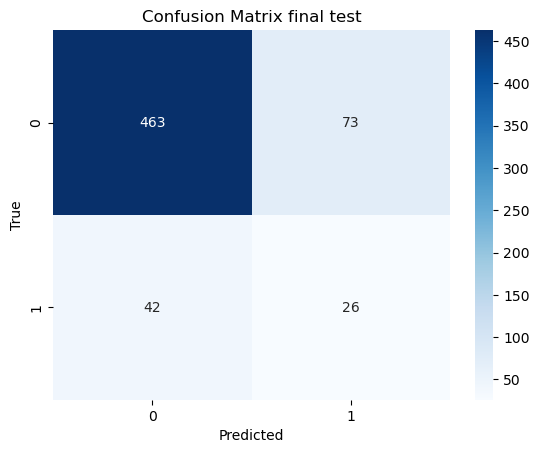

              precision    recall  f1-score   support

           0      0.917     0.864     0.890       536
           1      0.263     0.382     0.311        68

    accuracy                          0.810       604
   macro avg      0.590     0.623     0.600       604
weighted avg      0.843     0.810     0.824       604

ROC AUC: 0.764


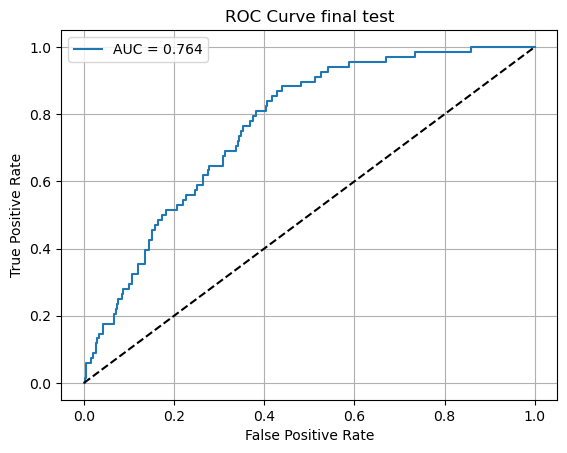

In [115]:
y_prob1 = clf1.predict_proba(X_val)[:, 1]
y_pred1 = (y_prob1 >= 0.2).astype(int)

cm = confusion_matrix(y_val, y_pred1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred1, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_val, y_prob1)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob1)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

In [98]:
def create_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


Sprawdzenie istotności cech korzystając ze zbioru walidacyjnego

PermutationExplainer explainer: 605it [20:31,  2.06s/it]                         


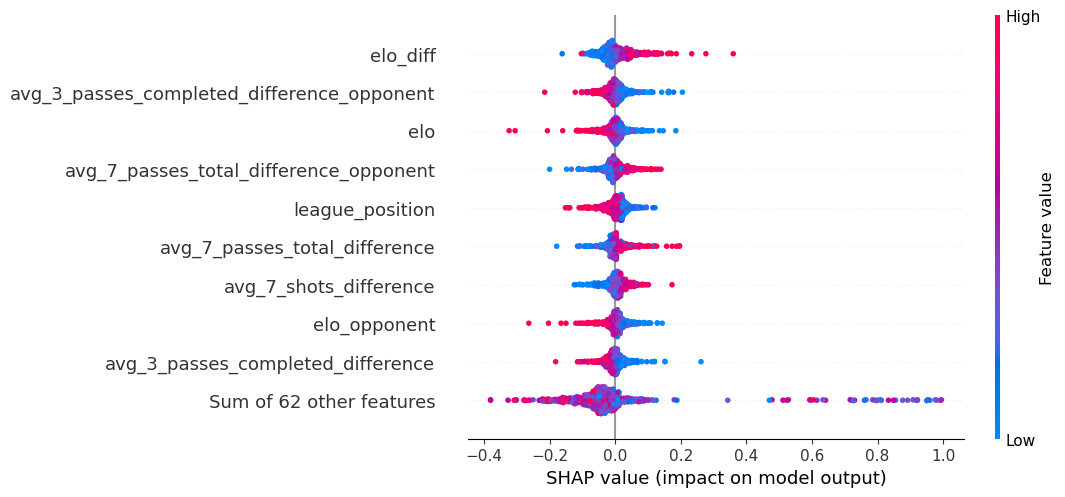

In [99]:
explainer = shap.Explainer(clf1.predict, X_val)  # clf to Twoja sieć
shap_values = explainer(X_val)

shap.plots.beeswarm(shap_values)

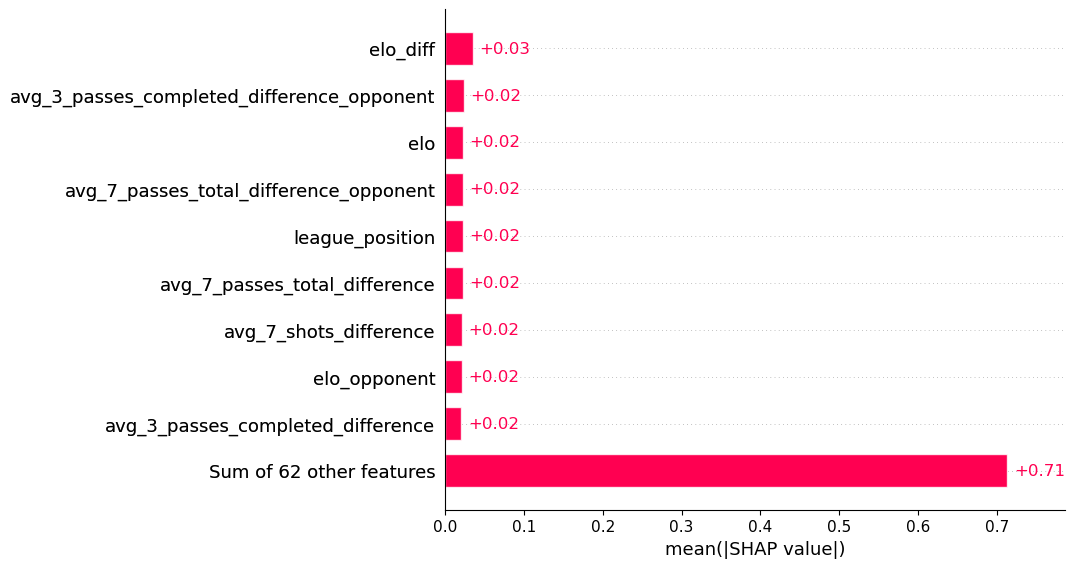

In [100]:
shap.plots.bar(shap_values)

Krosswalidacja modeli tworzonych na podstawie n najistotniejszych cech wg SHAP w celu selekcji cech

In [128]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.base import clone


def model_CV(X, y, n_split=5):
    tscv = TimeSeriesSplit(n_splits=n_split)
    scores = []
    i = 1
    for train_idx, val_idx in tscv.split(X.index):
        print(f"fold {i}")
        # Podział danych
        X_train_CV, X_val_CV = X.iloc[train_idx], X.iloc[val_idx]
        y_train_CV, y_val_CV = y.iloc[train_idx], y.iloc[val_idx]

        # Opakowanie modelu
        clf_fold = KerasClassifier(
            model=create_model, 
            input_dim=X_train_CV.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
            epochs=10, 
            batch_size=32,
            verbose=0, 
            shuffle=False, 
            random_state=42)
        # clf = create_model(X_train)

        # 🏋️‍♂️ Trening
        clf_fold.fit(X_train_CV, y_train_CV, epochs=20, batch_size=32, verbose=0)

        # 🔍 Predykcja i metryka
        y_prob_CV = clf_fold.predict_proba(X_val_CV)[:, 1]
        y_pred_CV = (y_prob_CV > 0.2).astype(int)  
        
        score = f1_score(y_val_CV, y_pred_CV)
        
        scores.append(score)
        i += 1
    return pd.Series(scores)

def shap_feature_selection(X, y, model, shap_vals, steps, scoring='f1'):

    mean_abs = np.abs(shap_vals.values).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]  # od najważniejszych

    mean_shap_df = pd.DataFrame(data={
        'feature': shap_vals.feature_names,
        'mean_abs_shap': mean_abs
    })

    results = []
    for k in steps:
        print(f"{k} features")
        keep_idx = order[:k]
        X_sel = X.iloc[:, keep_idx]

        scores = model_CV(X_sel, y, n_split=5)
        results.append({
            "n_features": k,
            "mean_score": scores.mean(),
            "std_score": scores.std(),
            "max_score": scores.max(),
            "features": list(X_sel.columns)
        })
        print(scores.mean(), scores.std(), scores.max())
    return results, mean_shap_df
n_features = [28, 30, 32, 35, 38, 40, 45, 50, len(X_val.columns)]
results, mean_shap_df = shap_feature_selection(X_train, y_train, clf1, shap_values, n_features)

28 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.28457769525679766 0.053172311896818245 0.35398230088495575
30 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.2954014040249455 0.05212288656469415 0.3670212765957447
32 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.28584278131428786 0.05463524013764905 0.34444444444444444
35 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.271366107833284 0.04212464739095793 0.31893687707641194
38 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.2885467121202189 0.0459443482487267 0.3591331269349845
40 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.2818792293440181 0.04755757147976561 0.34459459459459457
45 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.28391857302240187 0.05482569347419795 0.3363914373088685
50 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.27882604910687087 0.04492176468783741 0.3217665615141956
71 features
fold 1
fold 2
fold 3
fold 4
fold 5
0.26065856858499803 0.05467926360950212 0.32752613240418116


In [129]:
results[5]['features']

['elo_diff',
 'avg_3_passes_completed_difference_opponent',
 'elo',
 'avg_7_passes_total_difference_opponent',
 'league_position',
 'avg_7_passes_total_difference',
 'avg_7_shots_difference',
 'elo_opponent',
 'avg_3_passes_completed_difference',
 'season_goals_difference',
 'avg_7_shots_difference_opponent',
 'last_1_shots_difference',
 'avg_5_h/a_xG_difference_opponent',
 'avg_5_h/a_goals_difference',
 'avg_5_h/a_xG_difference',
 'avg_3_shots_difference',
 'season_points_opponent',
 'avg_3_shots_difference_opponent',
 'last_1_xG_difference',
 'league_position_opponent',
 'last_1_shots_difference_opponent',
 'avg_7_corners_difference_opponent',
 'last_1_xG_difference_opponent',
 'avg_7_goals_difference',
 'avg_3_crosses_difference_opponent',
 'avg_5_h/a_shots_on_target_difference',
 'season_goals_difference_opponent',
 'season_points',
 'avg_5_h/a_shots_difference',
 'avg_7_goals_difference_opponent',
 'avg_3_xG_difference',
 'avg_3_shots_on_target_difference',
 'avg_5_h/a_corners_dif

In [130]:
cols = results[5]['features']
cols

['elo_diff',
 'avg_3_passes_completed_difference_opponent',
 'elo',
 'avg_7_passes_total_difference_opponent',
 'league_position',
 'avg_7_passes_total_difference',
 'avg_7_shots_difference',
 'elo_opponent',
 'avg_3_passes_completed_difference',
 'season_goals_difference',
 'avg_7_shots_difference_opponent',
 'last_1_shots_difference',
 'avg_5_h/a_xG_difference_opponent',
 'avg_5_h/a_goals_difference',
 'avg_5_h/a_xG_difference',
 'avg_3_shots_difference',
 'season_points_opponent',
 'avg_3_shots_difference_opponent',
 'last_1_xG_difference',
 'league_position_opponent',
 'last_1_shots_difference_opponent',
 'avg_7_corners_difference_opponent',
 'last_1_xG_difference_opponent',
 'avg_7_goals_difference',
 'avg_3_crosses_difference_opponent',
 'avg_5_h/a_shots_on_target_difference',
 'season_goals_difference_opponent',
 'season_points',
 'avg_5_h/a_shots_difference',
 'avg_7_goals_difference_opponent',
 'avg_3_xG_difference',
 'avg_3_shots_on_target_difference',
 'avg_5_h/a_corners_dif

In [131]:
X_train2 = X_train[cols]
X_val2 = X_val[cols]
X_test2 = X_test[cols]

Sprawdzenie działania modelu po selekcji cech

In [179]:
clf2 = KerasClassifier(
    model=create_model, 
    input_dim=X_train2.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
    epochs=50, 
    batch_size=32,
    verbose=0, 
    shuffle=False, 
    random_state=42)
# clf = create_model(X_train)
clf2.fit(X_train2, y_train)


KerasClassifier(
	model=<function create_model at 0x000001A1CB54ECA0>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=40
	class_weight=None
)

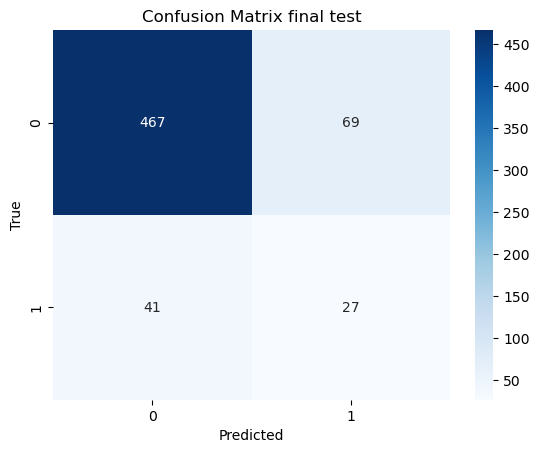

              precision    recall  f1-score   support

           0      0.919     0.871     0.895       536
           1      0.281     0.397     0.329        68

    accuracy                          0.818       604
   macro avg      0.600     0.634     0.612       604
weighted avg      0.847     0.818     0.831       604

ROC AUC: 0.754


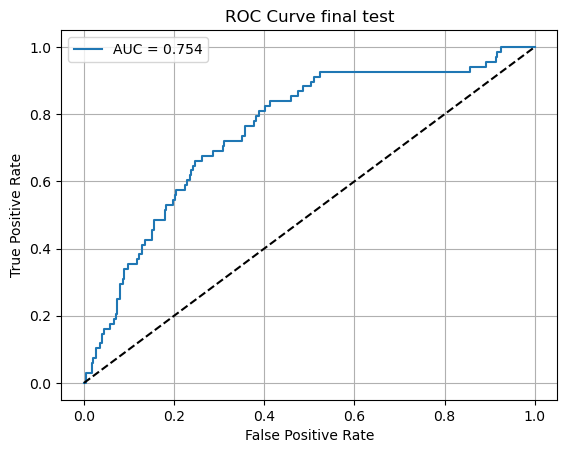

In [180]:
y_prob2 = clf2.predict_proba(X_val2)[:, 1]
y_pred2 = (y_prob2 >= 0.2).astype(int)

cm = confusion_matrix(y_val, y_pred2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred2, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_val, y_prob2)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob2)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

szukanie optymalnych parametrów sieci

In [135]:
f05_scorer = make_scorer(fbeta_score, beta=0.4, pos_label=1)

In [140]:
def create_model_optimized(input_dim, dropout_rate, dense1_units, dense2_units, dense3_units, activation):
    model = Sequential([
        # Input(shape=(input_dim,)),
        # Dense(dense1_units, activation='relu'),
        # Dropout(dropout_rate),
        # Dense(dense2_units, activation='relu'),
        # Dropout(dropout_rate),
        # Dense(1, activation='sigmoid')
        Input(shape=(input_dim,)),
        Dense(dense1_units, activation=activation),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(dense2_units, activation=activation),
        Dropout(dropout_rate),
        Dense(dense3_units, activation=activation),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam', 
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model


In [159]:
# early_stop = EarlyStopping(
#     monitor="val_loss",  # lub 'loss' jeśli nie używasz walidacji
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

clf_opt = KerasClassifier(
    model=create_model_optimized, 
    verbose=0, 
    shuffle=False, 
    random_state=42,
    # fit__callbacks=[early_stop],
    # fit__validation_split=0.2
)

param_dist = {
    "batch_size": [16, 32, 64],
    "epochs": [30, 50, 70],
    "model__input_dim": [X_train2.shape[1]],  # nie tuninguje się
    "model__dropout_rate": [0.2, 0.3, 0.4, 0.5],  # musisz dodać dropout_rate jako parametr create_model
    "model__dense1_units": [128, 256, 512],
    "model__dense2_units": [32, 64, 128],
    "model__dense3_units": [16, 32, 64],
    "model__activation": ['relu', 'selu', 'elu']
}

search = RandomizedSearchCV(clf_opt, param_distributions=param_dist, cv=5, scoring=f05_scorer, n_iter=100, n_jobs=-1)
search.fit(X_train2, y_train)

c:\Users\gcich\anaconda3\envs\ADWNOZ\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model_optimized at 0x000001A28CC68180>, random_state=42, shuffle=False, verbose=0),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'batch_size': [16, 32, 64],
                                        'epochs': [30, 50, 70],
                                        'model__activation': ['relu', 'selu',
                                                              'elu'],
                                        'model__dense1_units': [128, 256, 512],
                                        'model__dense2_units': [32, 64, 128],
                                        'model__dense3_units': [16, 32, 64],
                                        'model__dropout_rate': [0.2, 0.3, 0.4,
                                                                0.5],
                                        'model__input_dim': [40]},
                   scoring=make_scorer(fbeta_score, response_method='predict', beta=0.4, pos_label=1))

In [160]:
print("Najlepsze parametry:", search.best_params_)
print("Najlepszy wynik Precision:", search.best_score_)

Najlepsze parametry: {'model__input_dim': 40, 'model__dropout_rate': 0.2, 'model__dense3_units': 32, 'model__dense2_units': 128, 'model__dense1_units': 256, 'model__activation': 'relu', 'epochs': 50, 'batch_size': 64}
Najlepszy wynik Precision: 0.2263646301779402


In [167]:
def create_model_best(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

clf_best = KerasClassifier(
    model=create_model_best, 
    input_dim=X_train2.shape[1],
    verbose=0, 
    shuffle=False, 
    random_state=42,
    epochs=50, 
    batch_size=64
    # fit__callbacks=[early_stop],
    # fit__validation_split=0.2
)
clf_best.fit(X_train2, y_train)

KerasClassifier(
	model=<function create_model_best at 0x000001A2AEE06B60>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=64
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=40
	class_weight=None
)

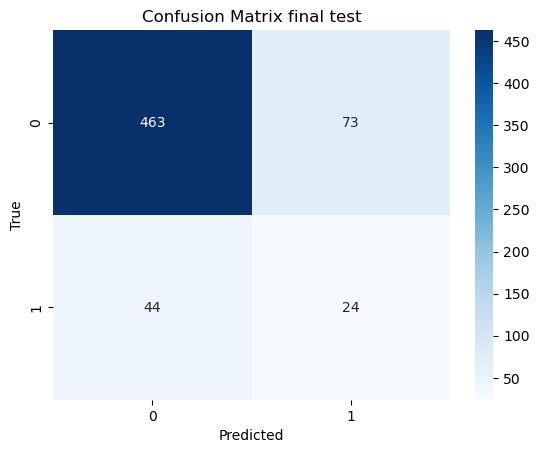

              precision    recall  f1-score   support

           0      0.913     0.864     0.888       536
           1      0.247     0.353     0.291        68

    accuracy                          0.806       604
   macro avg      0.580     0.608     0.589       604
weighted avg      0.838     0.806     0.821       604

ROC AUC: 0.748


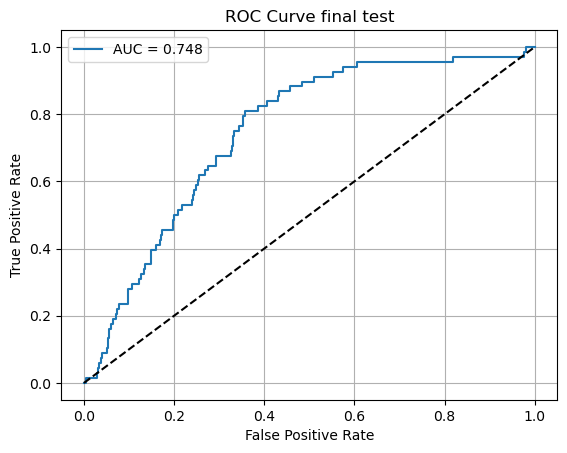

In [ ]:
y_prob_best = clf_best.predict_proba(X_val2)[:, 1]
y_pred_best = (y_prob_best >= 0.3).astype(int)

cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred_best, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_val, y_prob_best)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob_best)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

Optymalizacja hiperparametrów nie wyszła, lepsze wyniki osiągnęła sieć z domyślnymi parametrami

In [181]:
def create_model_the_best(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy', 
        metrics=[tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )
    return model

clf_the_best = KerasClassifier(
    model=create_model, 
    input_dim=X_train2.shape[1],  # <-- przekazujesz input_dim jako parametr modelu
    epochs=50, 
    batch_size=32,
    verbose=0, 
    shuffle=False, 
    random_state=42)

clf_the_best.fit(X_train2, y_train)



KerasClassifier(
	model=<function create_model at 0x000001A1CB54ECA0>
	build_fn=None
	warm_start=False
	random_state=42
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=False
	run_eagerly=False
	epochs=50
	input_dim=40
	class_weight=None
)

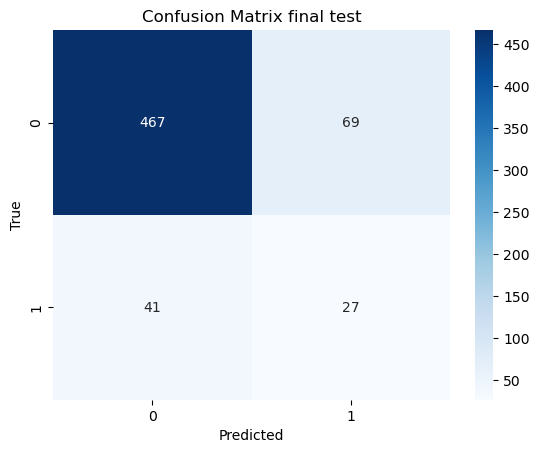

              precision    recall  f1-score   support

           0      0.919     0.871     0.895       536
           1      0.281     0.397     0.329        68

    accuracy                          0.818       604
   macro avg      0.600     0.634     0.612       604
weighted avg      0.847     0.818     0.831       604

ROC AUC: 0.754


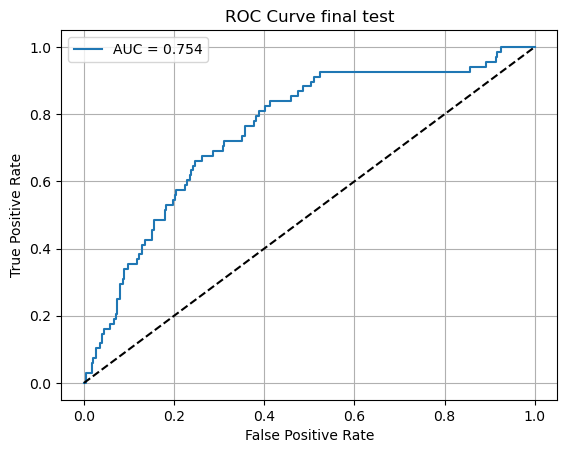

In [182]:
y_prob_the_best = clf_the_best.predict_proba(X_val2)[:, 1]
y_pred_the_best = (y_prob_the_best >= 0.2).astype(int)

cm = confusion_matrix(y_val, y_pred_the_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_val, y_pred_the_best, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_val, y_prob_the_best)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_val, y_prob_the_best)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()

test na zbiorze testowym

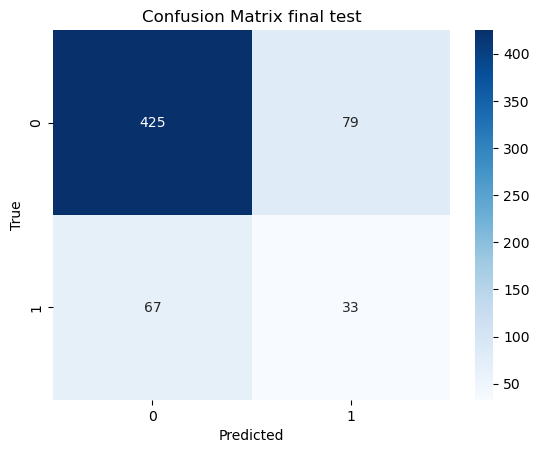

              precision    recall  f1-score   support

           0      0.864     0.843     0.853       504
           1      0.295     0.330     0.311       100

    accuracy                          0.758       604
   macro avg      0.579     0.587     0.582       604
weighted avg      0.770     0.758     0.764       604

ROC AUC: 0.688


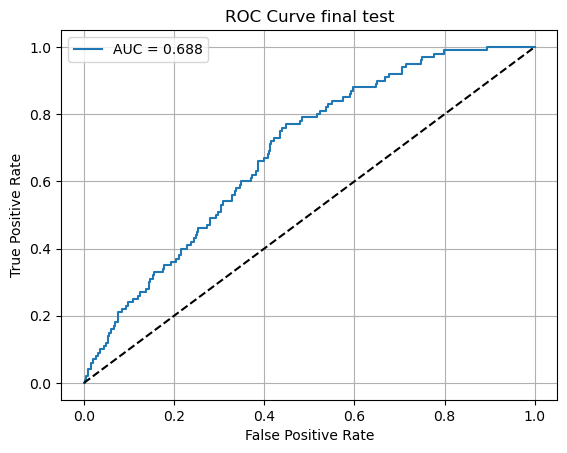

In [183]:
y_prob_the_best_test = clf_the_best.predict_proba(X_test2)[:, 1]
y_pred_the_best_test = (y_prob_the_best_test >= 0.2).astype(int)

cm = confusion_matrix(y_test, y_pred_the_best_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix final test')
plt.show()

# 2. Classification report
print(classification_report(y_test, y_pred_the_best_test, digits=3))

# 3. ROC AUC
auc_score = roc_auc_score(y_test, y_prob_the_best_test)
print(f"ROC AUC: {auc_score:.3f}")

# 4. Wykres ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_the_best_test)
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve final test')
plt.legend()
plt.grid(True)
plt.show()